In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import shuffle as sk_shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# Load dataset (Dataset-3.csv ONLY)
# Format: each row is a quoted string: "raw_value,Gesture"
# A UTF-8 BOM is present at the start of the file -> use utf-8-sig.
col_names = ['EMG', 'Gesture']

with open('Dataset-3.csv', 'r', encoding='utf-8-sig') as f:
    raw_lines = [ln.strip() for ln in f if ln.strip()]

records = []
for ln in raw_lines:
    cleaned = ln.strip().strip('"')   # strip surrounding quotes
    emg_str, gesture_str = cleaned.split(',', 1)
    records.append((emg_str, gesture_str))

df = pd.DataFrame(records, columns=col_names)
print(df.shape)
print(df['Gesture'].value_counts())

(2688, 2)
Gesture
Pinky&Ring    448
Middle        448
Index         448
Thumb         448
Fist          448
Rest          448
Name: count, dtype: int64


In [3]:
# Clean / validate EMG column and Gesture labels
df['EMG'] = pd.to_numeric(df['EMG'], errors='coerce')
df['Gesture'] = df['Gesture'].astype(str).str.strip().str.lower()

before = len(df)
df = df.dropna(subset=['EMG', 'Gesture']).reset_index(drop=True)
print(f"Dropped {before - len(df)} invalid rows")
print(df['Gesture'].unique())

# Dataset-3 has exactly 6 gestures: rest, fist, index, middle, thumb, pinky&ring.
# No bottle grip / open hand in this dataset -- that is correct, do not add them back.
expected_gestures = {'rest', 'fist', 'index', 'middle', 'thumb', 'pinky&ring'}
actual_gestures = set(df['Gesture'].unique())
assert actual_gestures == expected_gestures, (
    f"Unexpected gesture set: {actual_gestures}. "
    f"Expected exactly: {expected_gestures}"
)

Dropped 0 invalid rows
['pinky&ring' 'middle' 'index' 'thumb' 'fist' 'rest']


In [4]:
scaler = StandardScaler()
df['Normalized_EMG'] = scaler.fit_transform(df[['EMG']])

In [5]:
def extract_features(window):
    mav = np.mean(np.abs(window))
    rms = np.sqrt(np.mean(window**2))
    var = np.var(window)
    std = np.std(window)
    wl = np.sum(np.abs(np.diff(window)))
    zcr = np.sum(np.diff(np.sign(window)) != 0)
    ssc = np.sum(np.diff(np.sign(np.diff(window))) != 0)
    sk = skew(window)
    kt = kurtosis(window)
    iqr = np.percentile(window, 75) - np.percentile(window, 25)
    return [mav, rms, var, std, wl, zcr, ssc, sk, kt, iqr]

In [6]:
# Sliding window feature extraction — windows built in ORIGINAL SEQUENTIAL order
# per contiguous gesture block (no shuffling of raw rows here).
WINDOW_SIZE = 30
OVERLAP = 25
STEP = WINDOW_SIZE - OVERLAP

features_list = []
labels_list = []

for gesture in df['Gesture'].unique():
    block = df[df['Gesture'] == gesture].reset_index(drop=True)
    signal = block['Normalized_EMG'].values.astype(float)

    for i in range(0, len(signal) - WINDOW_SIZE, STEP):
        window = signal[i:i+WINDOW_SIZE]
        features_list.append(extract_features(window))
        labels_list.append(gesture)

feature_names = ['MAV','RMS','Variance','Std','WL','ZCR','SSC','Skew','Kurtosis','IQR']
X = pd.DataFrame(features_list, columns=feature_names)
y = pd.Series(labels_list)

print(X.shape)
print(y.value_counts())

(504, 10)
pinky&ring    84
middle        84
index         84
thumb         84
fist          84
rest          84
Name: count, dtype: int64


In [7]:
# Shuffle the resulting FEATURE rows (X, y) together — only after windows
# were extracted in sequential order above. Then stratified 80/20 split.
X, y = sk_shuffle(X, y, random_state=42)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)
print("Training complete")

Training complete


ACCURACY: 86.14%

              precision    recall  f1-score   support

        fist       0.71      0.75      0.73        16
       index       1.00      1.00      1.00        17
      middle       0.78      0.82      0.80        17
  pinky&ring       0.86      0.71      0.77        17
        rest       1.00      1.00      1.00        17
       thumb       0.83      0.88      0.86        17

    accuracy                           0.86       101
   macro avg       0.86      0.86      0.86       101
weighted avg       0.86      0.86      0.86       101

--- Index / Thumb detail (low signal variance, may confuse with Rest/each other) ---
 index: precision=1.000  recall=1.000  f1=1.000  support=17
 thumb: precision=0.833  recall=0.882  f1=0.857  support=17


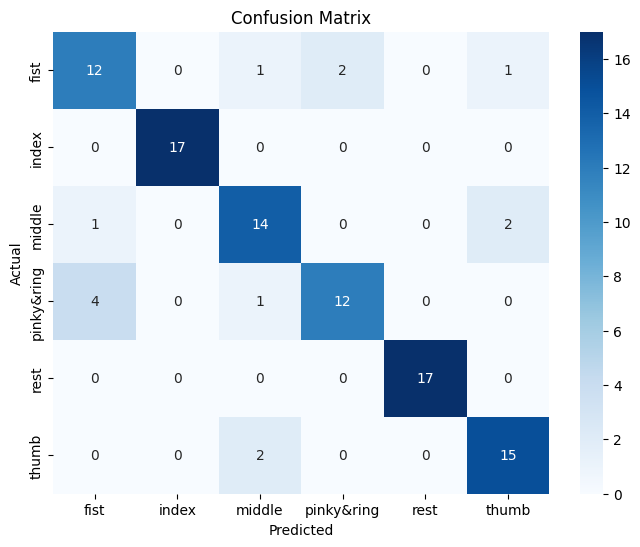

In [8]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"ACCURACY: {accuracy * 100:.2f}%\n")

report_dict = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred))

# Index and Thumb have low signal variance and may be confused with Rest
# or each other -- report their precision/recall explicitly.
print("--- Index / Thumb detail (low signal variance, may confuse with Rest/each other) ---")
for cls in ['index', 'thumb']:
    if cls in report_dict:
        m = report_dict[cls]
        print(f"{cls:>6}: precision={m['precision']:.3f}  recall={m['recall']:.3f}  "
              f"f1={m['f1-score']:.3f}  support={int(m['support'])}")

cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

if accuracy >= 0.98:
    print("WARNING: Accuracy >= 98% -- possible data leakage (e.g. overlapping "
          "sliding windows landing in both train and test after the shuffle, "
          "or scaler fit before splitting).")

In [9]:
joblib.dump(rf_model, 'ExoHand_RF_Model.joblib')
joblib.dump(scaler, 'ExoHand_Scaler.joblib')
print("Saved")

Saved
